# imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import mlflow
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV

c:\Users\Manindra\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# config

In [2]:
ASSET      = "AAPL"
INTERVAL   = "1h"
HORIZON    = "4h"
MLFLOW_URI = "http://localhost:5000"

# load data

In [3]:
train_df = pd.read_parquet(f'../../../data/processed/train_{ASSET.lower()}_{INTERVAL}_4h_target.parquet')
test_df  = pd.read_parquet(f'../../../data/processed/test_{ASSET.lower()}_{INTERVAL}_4h_target.parquet')

print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
print(f"Train period: {train_df.index.min()} to {train_df.index.max()}")
print(f"Test period : {test_df.index.min()} to {test_df.index.max()}")

Train shape : (2775, 31)
Test shape  : (694, 31)
Train period: 2024-05-13 16:30:00 to 2025-12-15 18:30:00
Test period : 2025-12-15 19:30:00 to 2026-05-11 15:30:00


# split features and targets

In [4]:
y_train = train_df['target_direction']
X_train = train_df.drop(columns=['target_4h', 'target_direction'], errors='ignore')
y_test  = test_df['target_direction']
X_test  = test_df.drop(columns=['target_4h', 'target_direction'], errors='ignore')
print(f"Number of features: {X_train.shape[1]}")

Number of features: 29


# mlflow

In [5]:
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment(f"{ASSET}_{INTERVAL}_{HORIZON}_XGBoost")
mlflow.xgboost.autolog(disable=True)
print("ok")

2026/05/13 13:05:26 INFO mlflow.tracking.fluent: Experiment with name 'AAPL_1h_4h_XGBoost' does not exist. Creating a new experiment.


ok


# run with mlflow

In [6]:
with mlflow.start_run(run_name=f"{ASSET}_{HORIZON}_XGBoost_Baseline"):
    baseline_model = xgb.XGBClassifier(
        n_estimators  = 100,
        learning_rate = 0.1,
        max_depth     = 5,
        eval_metric   = 'logloss',
        random_state  = 42
    )
    baseline_model.fit(X_train, y_train)
    y_pred       = baseline_model.predict(X_test)
    baseline_acc = accuracy_score(y_test, y_pred)
    mlflow.log_params({
        "n_estimators": 100, "learning_rate": 0.1,
        "max_depth": 5, "asset": ASSET,
        "horizon": HORIZON
    })
    mlflow.log_metric("test_accuracy", baseline_acc)
    print(f"\n--- {ASSET} {HORIZON} baseline done -----")
    print(f"Test Accuracy: {baseline_acc:.4f}")
    print(f"\n(Compare: 1h baseline was 0.5338)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


--- AAPL 4h baseline done -----
Test Accuracy: 0.4841

(Compare: 1h baseline was 0.5338)

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.25      0.32       339
           1       0.50      0.71      0.58       355

    accuracy                           0.48       694
   macro avg       0.47      0.48      0.45       694
weighted avg       0.47      0.48      0.46       694

🏃 View run AAPL_4h_XGBoost_Baseline at: http://localhost:5000/#/experiments/16/runs/e6fdf9eb15084706a6c0989c0576d463
🧪 View experiment at: http://localhost:5000/#/experiments/16


# feature importance

15 features for AAPL 4h prediction:
   1. ema_26_dist: 0.0560
   2. ema_50_dist: 0.0471
   3. macd_pct: 0.0460
   4. macd_hist_pct: 0.0440
   5. sma_200_dist: 0.0440
   6. macd_sig_pct: 0.0430
   7. ema_12_dist: 0.0424
   8. sma_50_dist: 0.0422
   9. roc_20: 0.0417
  10. vwap_dist: 0.0415
  11. rsi_14: 0.0414
  12. ema_200_dist: 0.0408
  13. sma_30_dist: 0.0404
  14. sma_100_dist: 0.0404
  15. sma_7_dist: 0.0403


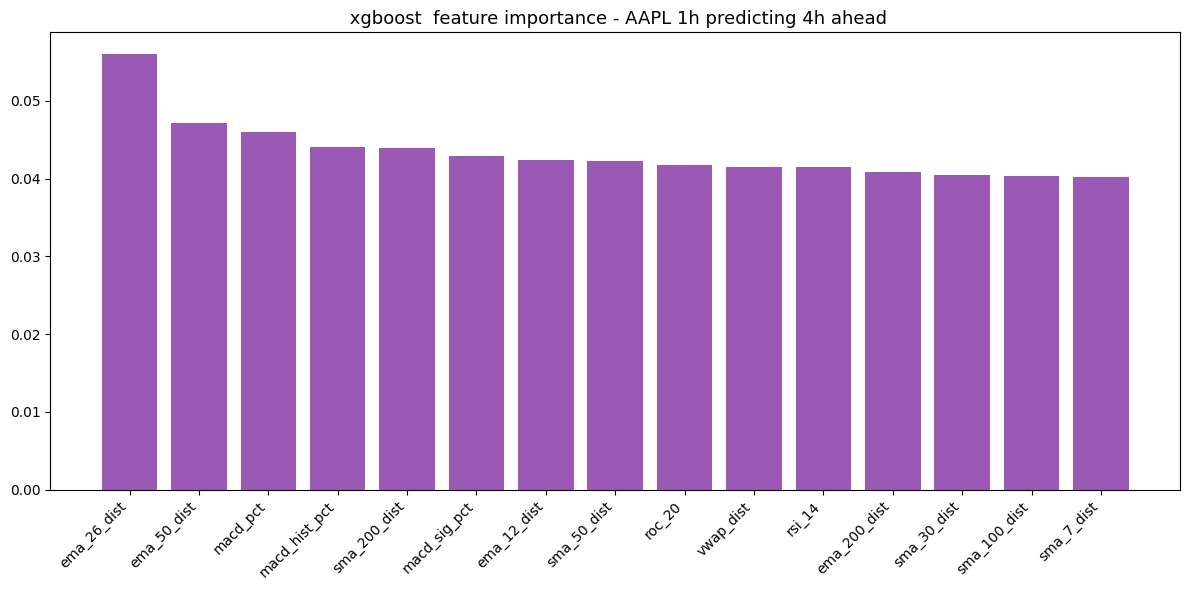

In [7]:
importances   = baseline_model.feature_importances_
feature_names = X_train.columns
indices       = np.argsort(importances)[::-1]

print(f"15 features for {ASSET} {HORIZON} prediction:")
for rank in range(min(15, len(feature_names))):
    fname = feature_names[indices[rank]]
    score = importances[indices[rank]]
    print(f"  {rank+1:2d}. {fname}: {score:.4f}")

plt.figure(figsize=(12, 6))
plt.title(f" xgboost  feature importance - {ASSET} {INTERVAL} predicting {HORIZON} ahead", fontsize=13)
plt.bar(range(15), importances[indices][:15], color="#9b59b6", align="center")
plt.xticks(range(15), [feature_names[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()
